This notebook evaluates the robustness of the FOVEA network after retraining against rotation attacks. We examine how performance degrades as images are rotated and compare these results with the baseline networks tested in script 17 to assess the impact of foveation on rotational invariance.

# Evaluating FOVEA network robustness across multiple rotation angles

In [1]:
import retinoto_py as fovea
args = fovea.Params(do_fovea=True, do_augment=False)
# args

In [2]:
all_angles = fovea.np.linspace(0, 180, 25)
all_angles

array([  0. ,   7.5,  15. ,  22.5,  30. ,  37.5,  45. ,  52.5,  60. ,
        67.5,  75. ,  82.5,  90. ,  97.5, 105. , 112.5, 120. , 127.5,
       135. , 142.5, 150. , 157.5, 165. , 172.5, 180. ])

In [3]:
# all_model_names = fovea.params.all_rn_model_names
# all_model_names.append('convnext_base')
all_model_names = ['convnext_base']
all_model_names

['convnext_base']

In [4]:
all_datasets = ['bbox']
all_datasets

['bbox']

In [5]:
# all_model_names = ['resnet18', 'resnet50', 'resnet101',  'convnext_base']
# all_model_names = fovea.params.all_rn_model_names
# all_model_names.append('convnext_base')
# all_model_names_ls = fovea.params.all_rn_model_names_ls
# all_model_names_ls.extend('o')
# all_model_names_ls = [ 'dashed', 'dashdot', 'dotted', 'solid', ]
all_model_names_ls = [':', '-.', '--', '-'] 
# all_model_names_color = ['yellow', 'orange', 'red', 'blue']
all_model_names_color = ['magenta', 'blue', 'orange', 'green']
all_model_names, all_model_names_ls, all_model_names_color

(['convnext_base'],
 [':', '-.', '--', '-'],
 ['magenta', 'blue', 'orange', 'green'])

In [6]:
delta_angle = all_angles[1] - all_angles[0]
all_angles_min = all_angles - delta_angle / 2
# all_angles_min, all_angles_min + delta_angle, delta_angle

In [7]:
for dataset in all_datasets:
    for model_name in all_model_names:
        npz_filename = args.data_cache / f'37_rotation-attack_name={model_name}_dataset={dataset}.npz'
        print(f'Rotation attack for {model_name=} and {dataset=} \t {npz_filename=}')

        # %rm {npz_filename}  # FORCING RECOMPUTE

        if npz_filename.exists():
            with fovea.np.load(npz_filename) as data:
                attack_angle = data['attack_angle']
                attack_success = data['attack_success']
                all_results = data['results']
        else:
            args = fovea.Params(shuffle=False, do_fovea=True, do_augment=False, model_name=model_name, batch_size=500)
            model_filename = args.data_cache / f'32_fovea_model_name={args.model_name}_dataset={dataset}.pth'
            model = fovea.load_model(args, model_filename=model_filename)
            model.eval()

            VAL_DATA_DIR = args.DATAROOT / f'Imagenet_{dataset}' / 'val'
            val_dataset = fovea.get_dataset(args, VAL_DATA_DIR)
            val_loader = fovea.get_loader(args, val_dataset)

            # https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html
            criterion = fovea.torch.nn.CrossEntropyLoss(reduction='none')
            # dataset_len = len(val_loader.dataset)
            all_results = fovea.np.empty((len(all_angles), len(val_loader.dataset)))
            all_logits = fovea.np.empty((len(all_angles), len(val_loader.dataset), len(val_dataset.classes)))  # model.fc.out_features
            all_losses = fovea.np.empty((len(all_angles), len(val_loader.dataset)))
            all_labels = []
            outer_progress = fovea.tqdm(
                                    enumerate(zip(all_angles_min, all_angles_min + delta_angle)),
                                    total=len(all_angles_min),
                                    desc="Validating Angles",
                                    leave=False
                                )
            for i_angle, (angle_min, angle_max) in outer_progress:
                val_dataset = fovea.get_dataset(args, VAL_DATA_DIR,
                                                angle_min=angle_min, angle_max=angle_max)
                val_loader = fovea.get_loader(args, val_dataset)

                # correct_predictions = 0
                # total_predictions = 0

                image_count = 0
                for images, true_idxs in fovea.tqdm(val_loader, desc=f"Angle [{.5*(angle_min+angle_max):.1f}°]", position=1, leave=False):
                    images = images.to(args.device)
                    true_idxs = true_idxs.to(args.device)

                    # Get predictions (no need for gradients)
                    with fovea.torch.no_grad():
                        if i_angle==0: all_labels.extend([l.item() for l in true_idxs])
                        outputs = model(images)
                        all_logits[i_angle, image_count:(image_count + images.size(0)), :] = outputs.cpu().numpy()

                        _, predicted_labels = fovea.torch.max(outputs, dim=1)
                        correct_predictions_in_batch = (predicted_labels == true_idxs).cpu().numpy()

                        all_results[i_angle, image_count:image_count + images.size(0)] = correct_predictions_in_batch
                        loss = criterion(outputs, true_idxs)
                        all_losses[i_angle, image_count:(image_count + images.size(0))] = loss.cpu().numpy()
                    image_count += images.size(0)
                outer_progress.set_postfix(last_acc=f"{all_results[i_angle, :].mean():.4f}")

            attack_angle = all_losses[:, :len(all_labels)].argmax(axis=0)
            attack_idx = all_logits[attack_angle[:len(all_labels)], fovea.np.arange(len(all_labels)), :].argmax(axis=1)
            attack_success = (attack_idx == all_labels)

            fovea.np.savez(npz_filename,
                    attack_angle=attack_angle,
                    attack_success=attack_success,
                    results=all_results)



Rotation attack for model_name='convnext_base' and dataset='bbox' 	 npz_filename=PosixPath('cached_data/37_rotation-attack_name=convnext_base_dataset=bbox.npz')


# Analysis: Mean accuracy vs. rotation angle

In [8]:
all_results.shape

(25, 80475)

In [9]:
all_results.mean(axis=1)

array([0.79309102, 0.7908046 , 0.78951227, 0.78732526, 0.78522523,
       0.78267785, 0.77718546, 0.76951848, 0.76239826, 0.7558745 ,
       0.75068034, 0.74685306, 0.74500155, 0.74092575, 0.74133582,
       0.74287667, 0.74329916, 0.74532463, 0.74652998, 0.74594595,
       0.74808326, 0.74773532, 0.74884126, 0.74889096, 0.74904007])

In [10]:
# all_model_names_ls

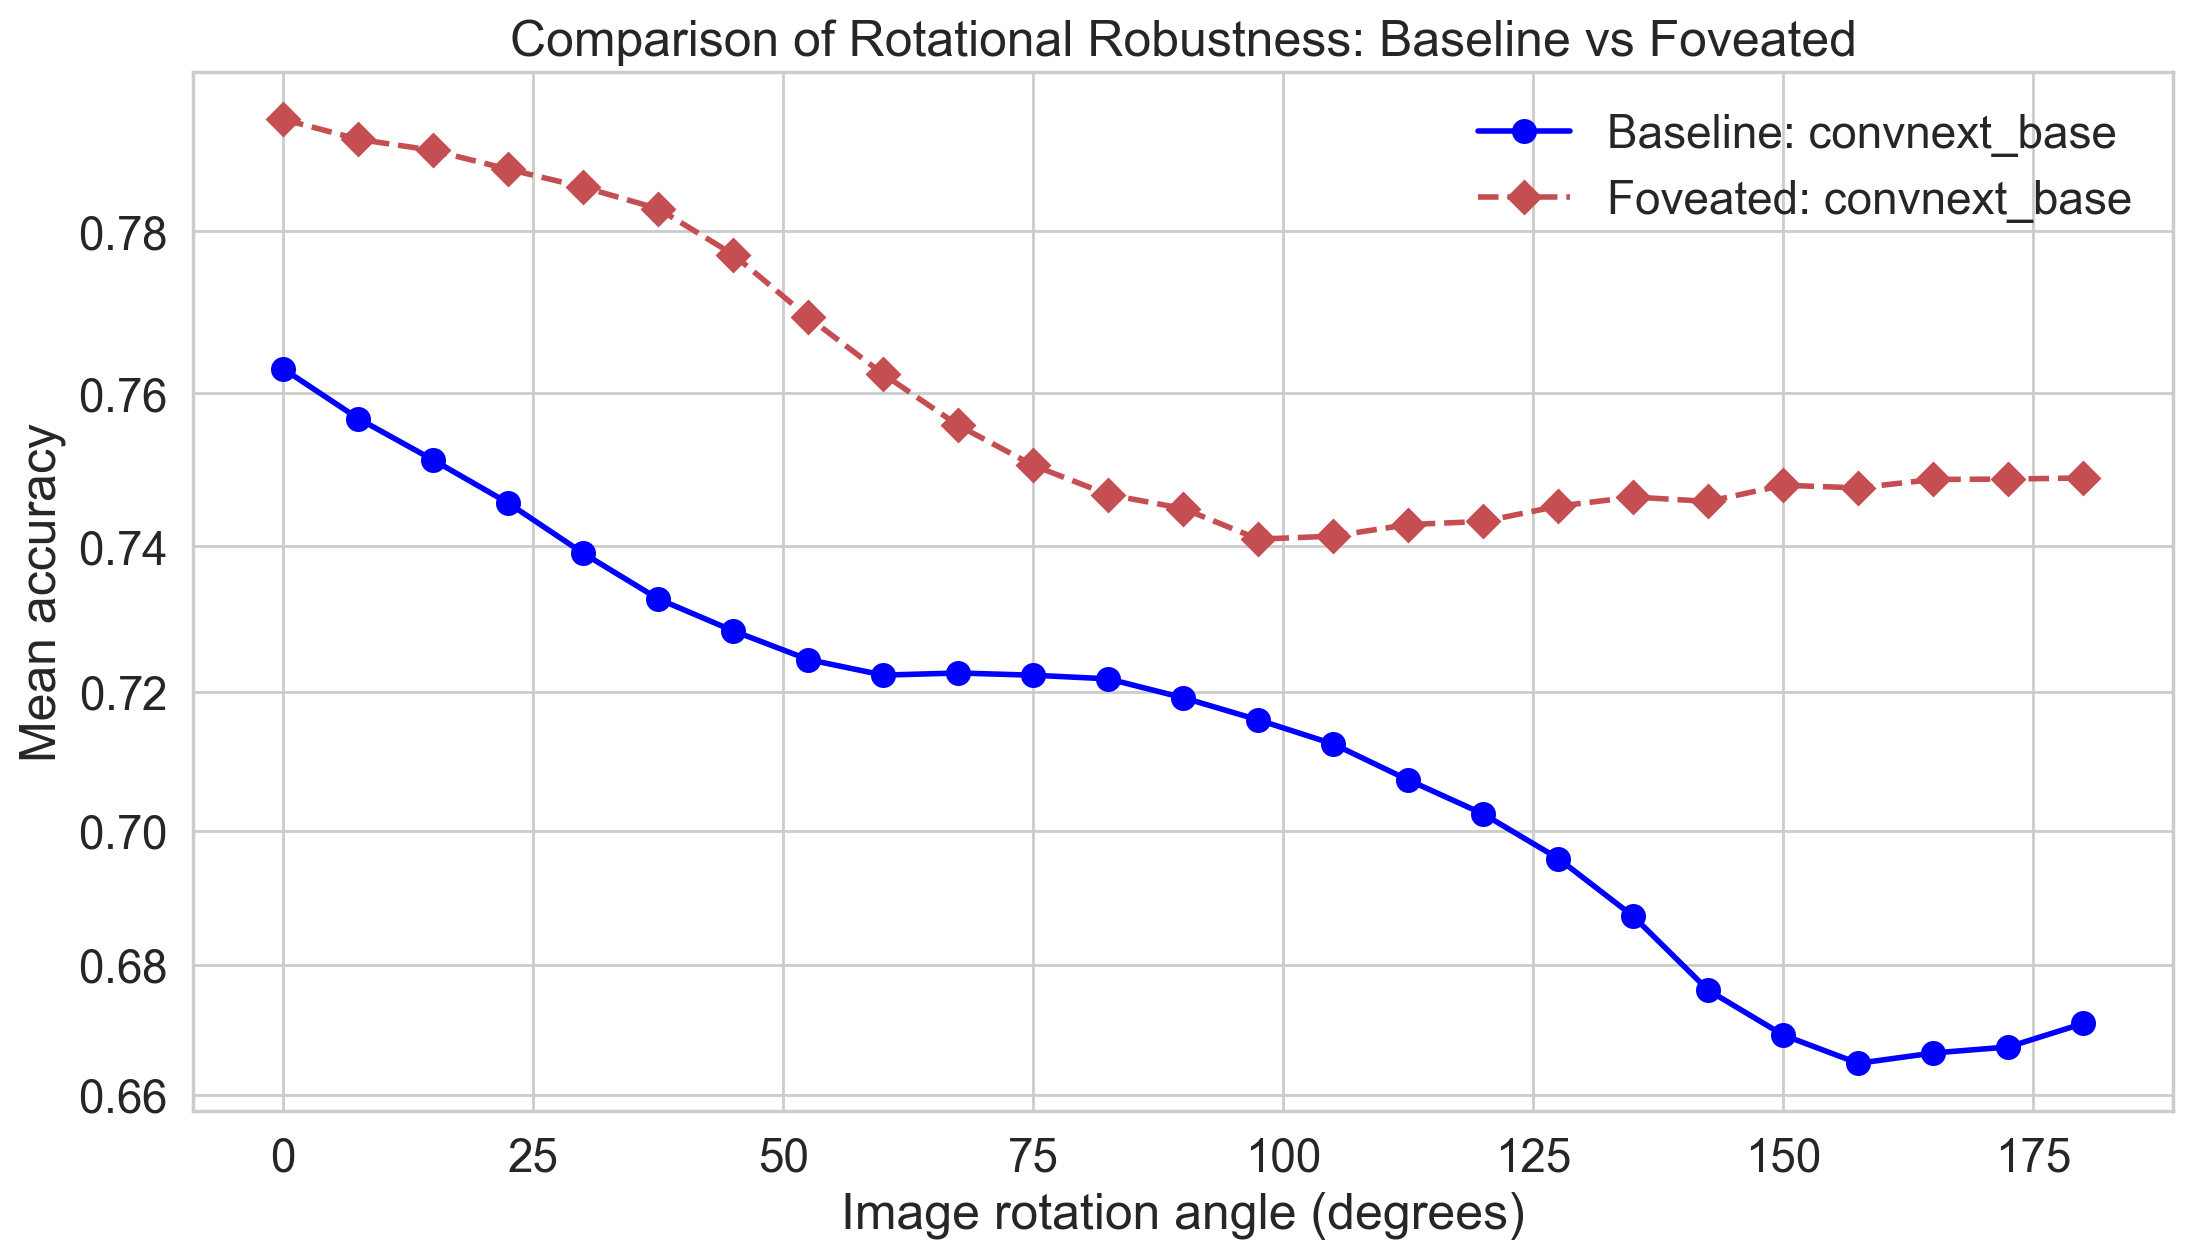

In [11]:
# --- Create the Plot ---
fig, ax = fovea.plt.subplots()

for dataset in all_datasets:
    color = fovea.params.all_datasets_color[0] if len(all_datasets)==1 else fovea.params.all_datasets_color[all_datasets.index(dataset)]
    
    # 1. Plot Baseline (from script 17)
    for model_name in all_model_names:
        npz_baseline = args.data_cache / f'17_rotation-attack_name={model_name}_dataset={dataset}.npz'
        if npz_baseline.exists():
            with fovea.np.load(npz_baseline) as data:
                acc = data['results'].mean(axis=1)
            ax.plot(all_angles, acc, marker='o', linestyle='-', color=color, lw=2, markersize=8, label=f'Baseline: {model_name}')

    # 2. Plot Foveated Retrained (from script 37)
    for model_name in all_model_names:
        npz_fovea = args.data_cache / f'37_rotation-attack_name={model_name}_dataset={dataset}.npz'
        if npz_fovea.exists():
            with fovea.np.load(npz_fovea) as data:
                acc = data['results'].mean(axis=1)
            ax.plot(all_angles, acc, marker='D', linestyle='--', color='r', lw=2, markersize=8, label=f'Foveated: {model_name}')

# --- Finalize the Plot ---
ax.set_xlabel("Image rotation angle (degrees)")
ax.set_ylabel("Mean accuracy")
ax.set_title("Comparison of Rotational Robustness: Baseline vs Foveated")
ax.set_yscale('logit')
ax.legend(frameon=False)
fovea.savefig(fig, name='37_attack_comparison', figures_folder=args.figures_folder, exts=['pdf'])


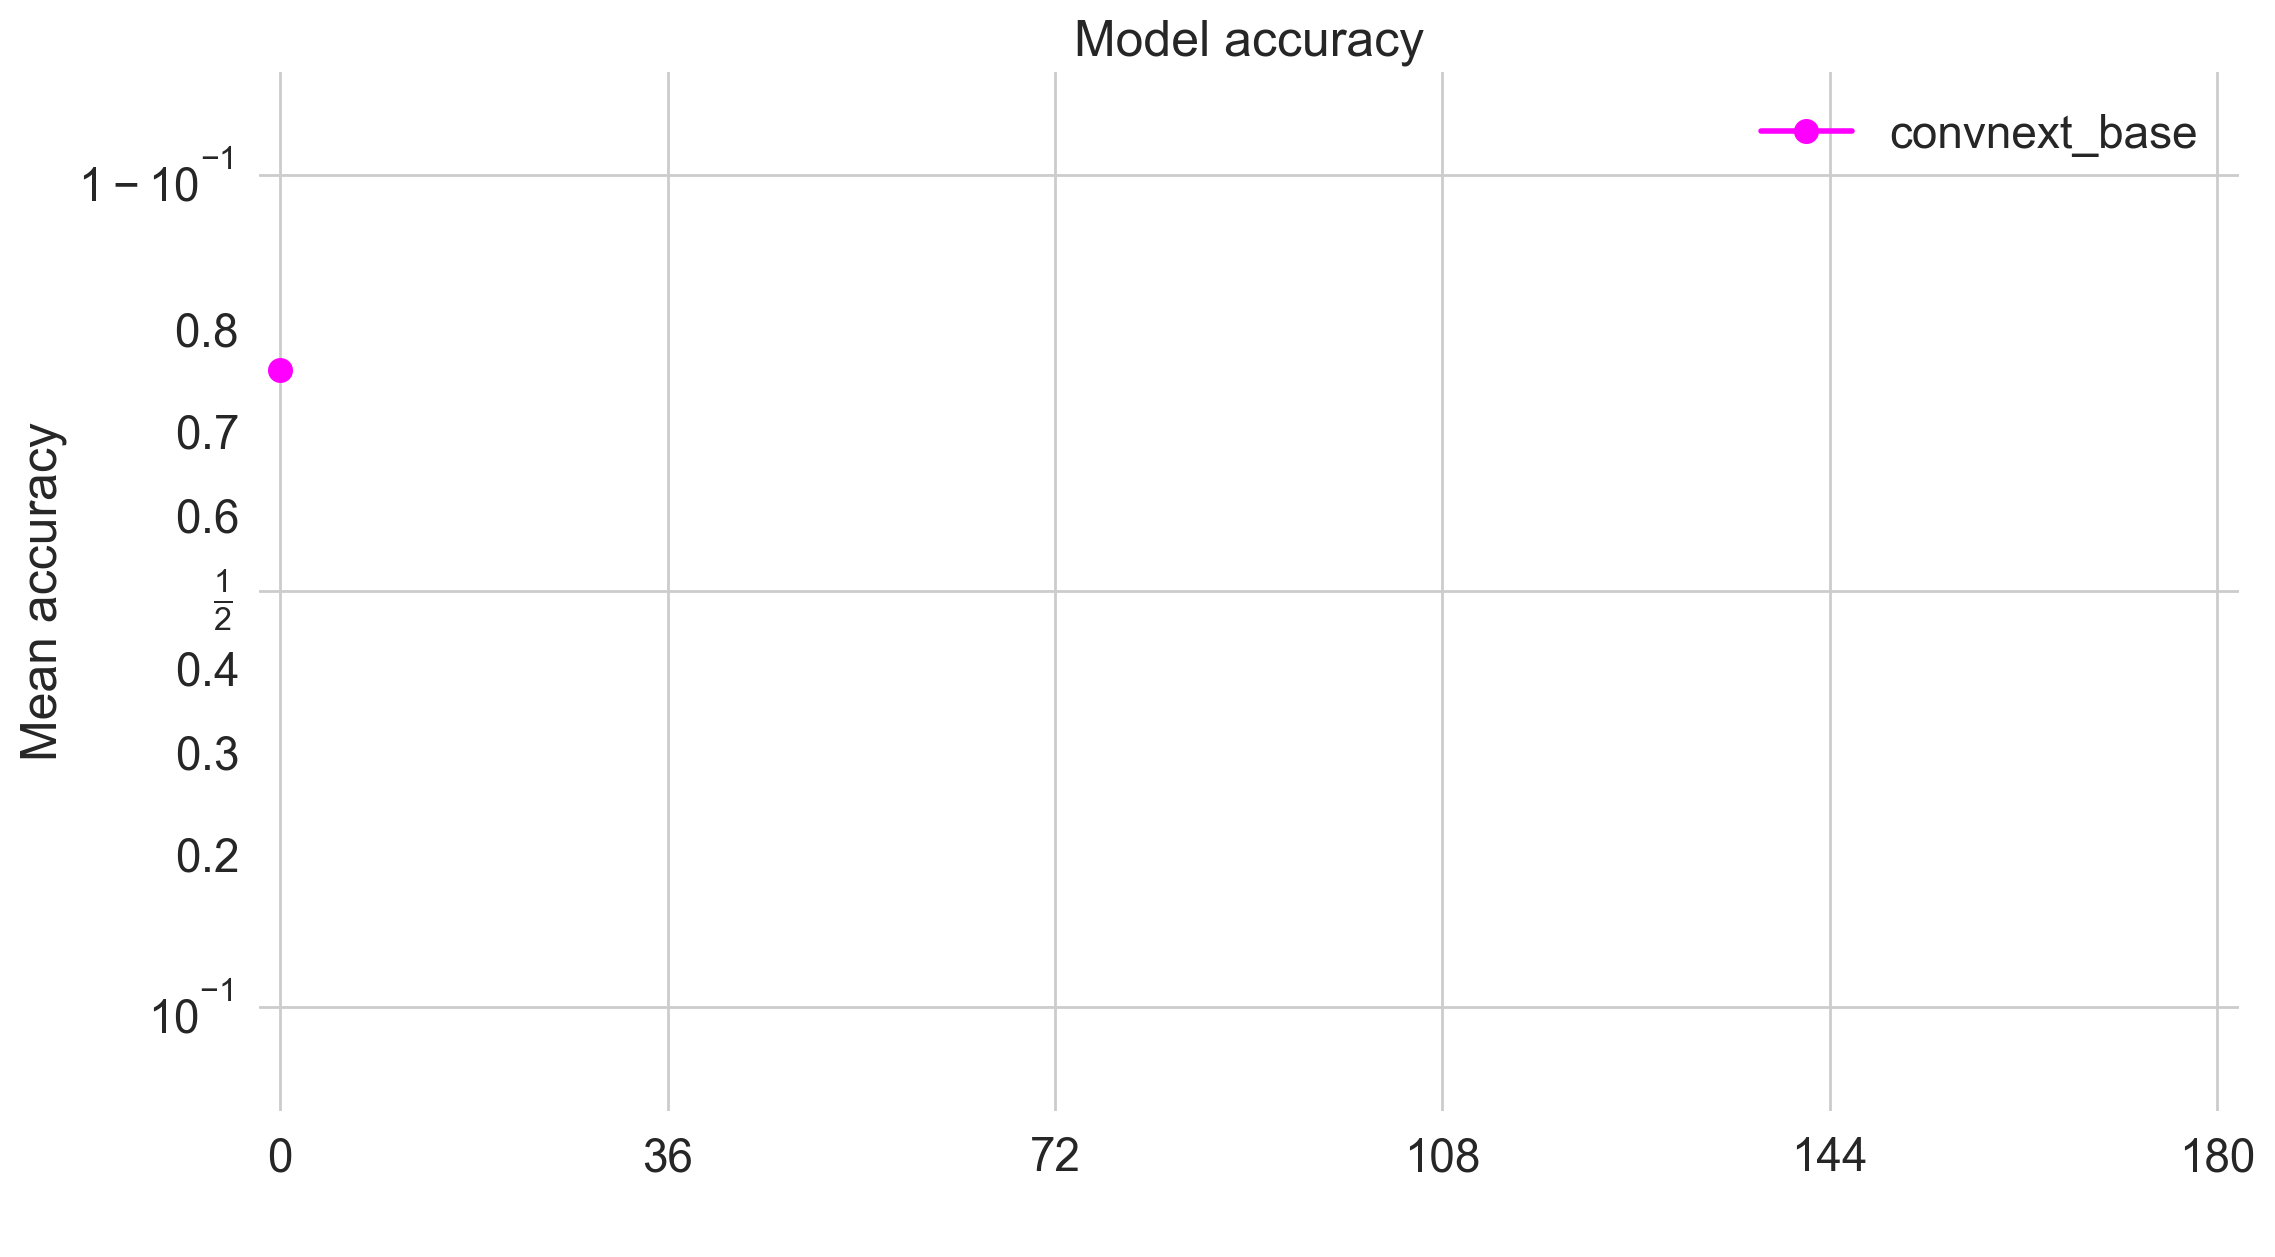

In [12]:
# --- Create the Plot ---
fig, ax = fovea.plt.subplots()
for model_name, c in zip(all_model_names, all_model_names_color):
    npz_filename = args.data_cache / f'17_rotation-attack_name={model_name}_dataset={dataset}.npz'
    with fovea.np.load(npz_filename) as data:
        all_results = data['results']
    # `all_results` is a boolean array (True/False for correct/incorrect)
    # To compute accuracy, average over the image axis (axis=1)
    mean_accuracy_per_angle = all_results.mean(axis=1)

    # Plot mean accuracy vs. reference angle
    ax.plot(all_angles[0], mean_accuracy_per_angle[0], marker='o', color=c, lw=2, markersize=8, label=model_name)

# model_name = 'convnext_base'
# npz_filename = args.data_cache / f'37_rotation-attack_name={model_name}_dataset={dataset}.npz'
# with fovea.np.load(npz_filename) as data:
#     all_results = data['results']
# mean_accuracy_per_angle = all_results.mean(axis=1)
# ax.plot(all_angles[0], mean_accuracy_per_angle[0], marker='D', linestyle=ls, color='r', lw=2, markersize=8, label='Foveated')

# --- Finalize the Plot ---
ax.set_xlabel(" ")
ax.set_ylabel("Mean accuracy")
ax.set_title("Model accuracy")
# ax.set_ylim(0, 1.05)  # Ensure y axis spans 0 to 1
ax.set_yscale('logit')  # Ensure y axis spans 0 to 1
ax.set_xticks(fovea.np.linspace(0, 180, 6))  # Ensure y axis spans 0 to 1
ax.set_xlim(-2, 182)  # Ensure y axis spans 0 to 1

# Build legends
# for dataset, color in zip(all_datasets, fovea.params.all_datasets_color):
#     ax.plot([], [], linestyle='-', color=color, lw=2, label=dataset)
# for model_name, ls in zip(all_model_names, fovea.params.all_rn_model_names_ls):
#     ax.plot([], [], linestyle=ls, color='k', lw=2, markersize=8, label=model_name)
ax.legend(frameon=False)
for spine in ax.spines.values():
        spine.set_visible(False)
fovea.savefig(fig, name='37_attack_doublezero', figures_folder=args.figures_folder, exts=['pdf'])


NameError: name 'ls' is not defined

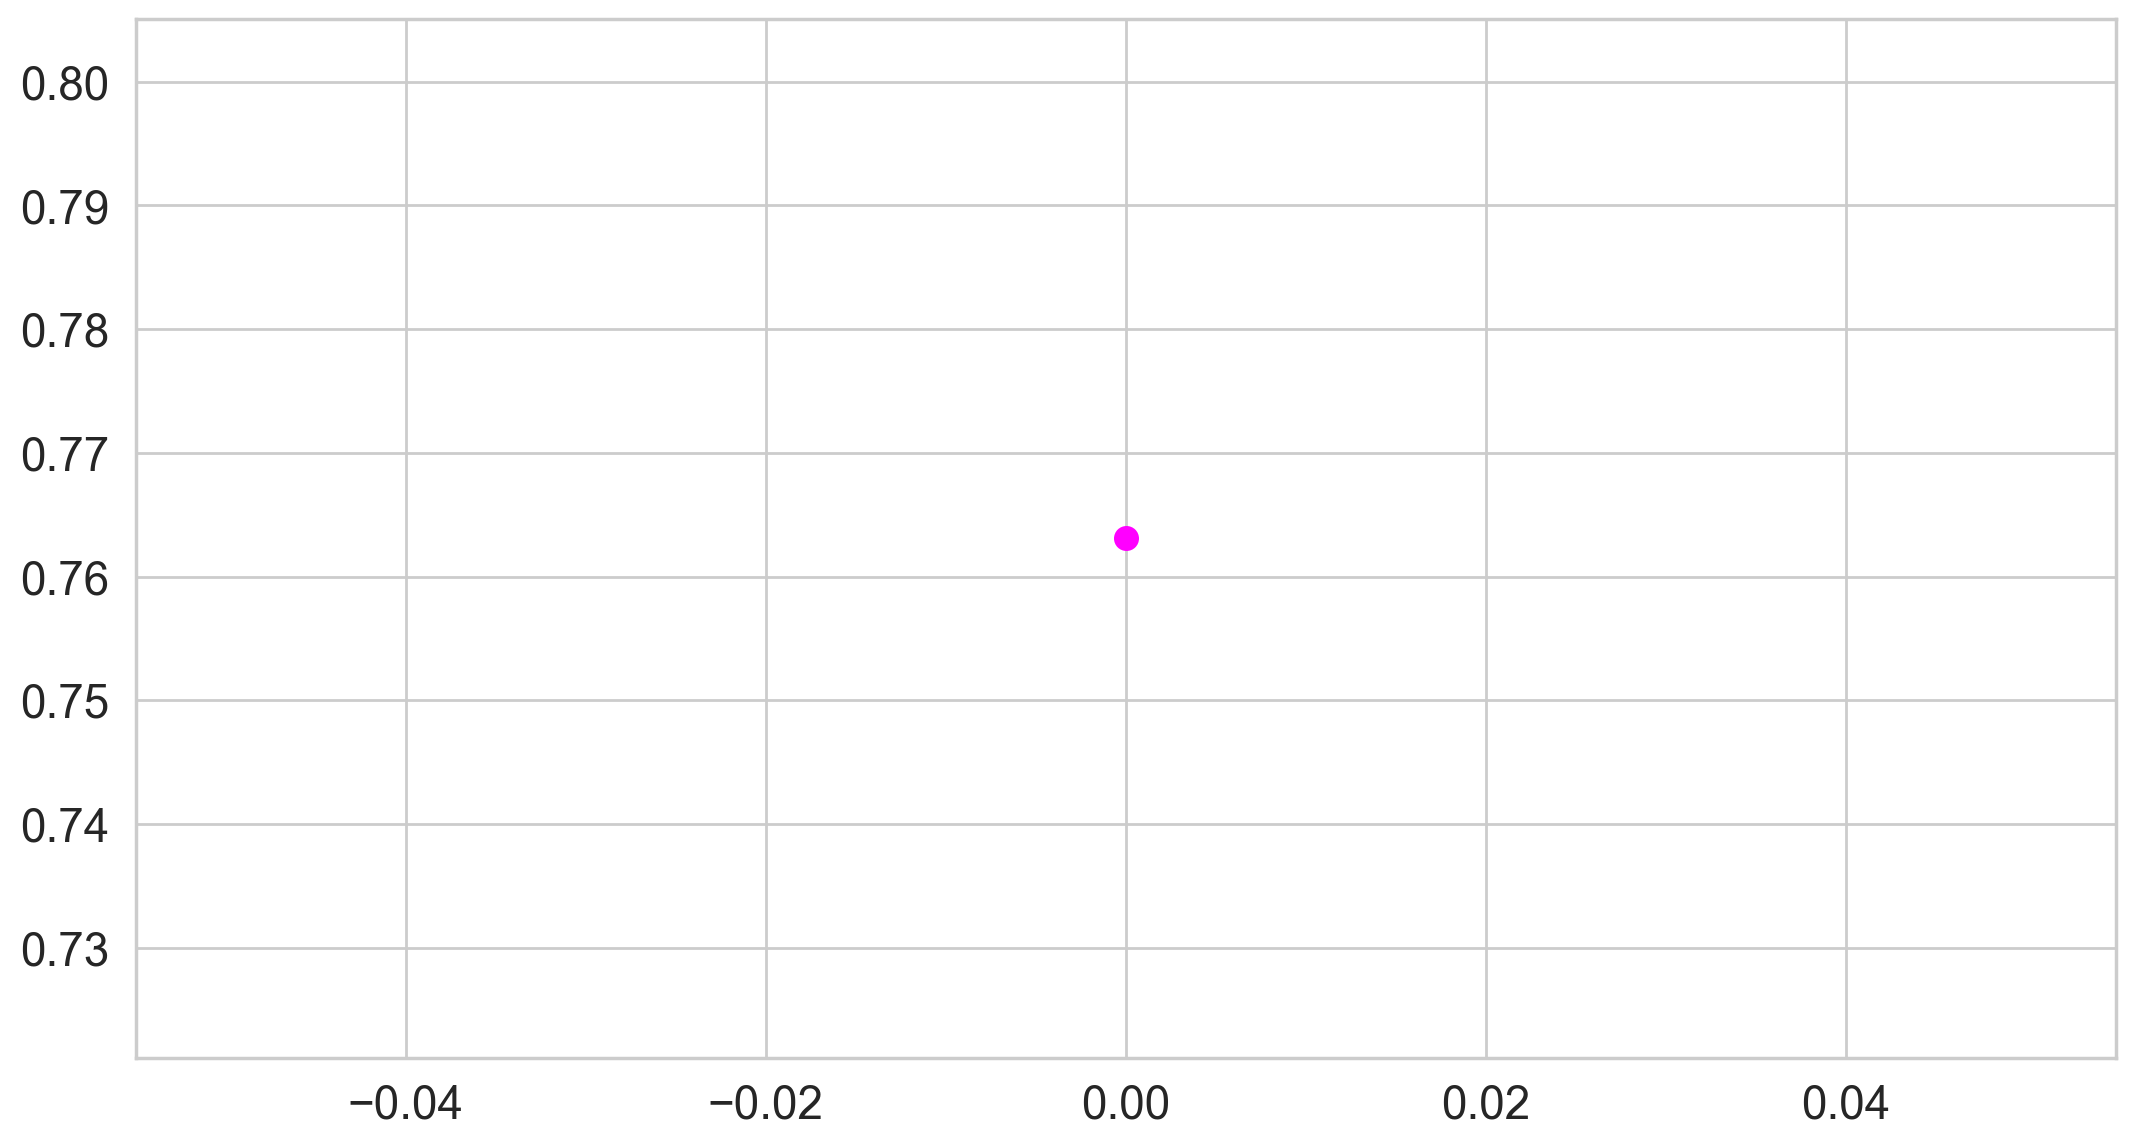

In [13]:
# --- Create the Plot ---
fig, ax = fovea.plt.subplots()
for model_name, c in zip(all_model_names, all_model_names_color):
    npz_filename = args.data_cache / f'17_rotation-attack_name={model_name}_dataset={dataset}.npz'
    with fovea.np.load(npz_filename) as data:
        all_results = data['results']
    # `all_results` is a boolean array (True/False for correct/incorrect)
    # To compute accuracy, average over the image axis (axis=1)
    mean_accuracy_per_angle = all_results.mean(axis=1)

    # Plot mean accuracy vs. reference angle
    ax.plot(all_angles[0], mean_accuracy_per_angle[0], marker='o', color=c, lw=2, markersize=8, label=model_name)

model_name = 'convnext_base'
npz_filename = args.data_cache / f'37_rotation-attack_name={model_name}_dataset={dataset}.npz'
with fovea.np.load(npz_filename) as data:
    all_results = data['results']
mean_accuracy_per_angle = all_results.mean(axis=1)
ax.plot(all_angles[0], mean_accuracy_per_angle[0], marker='D', linestyle=ls, color='r', lw=2, markersize=8, label='Foveated')

# --- Finalize the Plot ---
ax.set_xlabel(" ")
ax.set_ylabel("Mean accuracy")
ax.set_title("Model accuracy")
# ax.set_ylim(0, 1.05)  # Ensure y axis spans 0 to 1
ax.set_yscale('logit')  # Ensure y axis spans 0 to 1
ax.set_xticks(fovea.np.linspace(0, 180, 6))  # Ensure y axis spans 0 to 1
ax.set_xlim(-2, 182)  # Ensure y axis spans 0 to 1

# Build legends
# for dataset, color in zip(all_datasets, fovea.params.all_datasets_color):
#     ax.plot([], [], linestyle='-', color=color, lw=2, label=dataset)
# for model_name, ls in zip(all_model_names, fovea.params.all_rn_model_names_ls):
#     ax.plot([], [], linestyle=ls, color='k', lw=2, markersize=8, label=model_name)
ax.legend(frameon=False)
for spine in ax.spines.values():
        spine.set_visible(False)
fovea.savefig(fig, name='37_attack_zero', figures_folder=args.figures_folder, exts=['pdf'])


In [ ]:
# --- Create the Plot ---
fig, ax = fovea.plt.subplots()
for model_name, c in zip(all_model_names, all_model_names_color):
    npz_filename = args.data_cache / f'17_rotation-attack_name={model_name}_dataset={dataset}.npz'
    with fovea.np.load(npz_filename) as data:
        all_results = data['results']
    # `all_results` is a boolean array (True/False for correct/incorrect)
    # To compute accuracy, average over the image axis (axis=1)
    mean_accuracy_per_angle = all_results.mean(axis=1)

    # Plot mean accuracy vs. reference angle
    ax.plot(all_angles, mean_accuracy_per_angle, marker='o', color=c, lw=2, markersize=8, label=model_name)

model_name = 'convnext_base'
npz_filename = args.data_cache / f'37_rotation-attack_name={model_name}_dataset={dataset}.npz'
with fovea.np.load(npz_filename) as data:
    all_results = data['results']
mean_accuracy_per_angle = all_results.mean(axis=1)
ax.plot(all_angles, mean_accuracy_per_angle, marker='D', linestyle=ls, color='r', lw=2, markersize=8, label='Foveated')

# --- Finalize the Plot ---
ax.set_xlabel("Image rotation angle (degrees)")
ax.set_ylabel("Mean accuracy")
ax.set_title("Model robustness to rotations")
# ax.set_ylim(0, 1.05)  # Ensure y axis spans 0 to 1
ax.set_yscale('logit')  # Ensure y axis spans 0 to 1
ax.set_xticks(fovea.np.linspace(0, 180, 6))  # Ensure y axis spans 0 to 1
ax.set_xlim(-2, 182)  # Ensure y axis spans 0 to 1

# Build legends
# for dataset, color in zip(all_datasets, fovea.params.all_datasets_color):
#     ax.plot([], [], linestyle='-', color=color, lw=2, label=dataset)
# for model_name, ls in zip(all_model_names, fovea.params.all_rn_model_names_ls):
#     ax.plot([], [], linestyle=ls, color='k', lw=2, markersize=8, label=model_name)
ax.legend(frameon=False)
for spine in ax.spines.values():
        spine.set_visible(False)
fovea.savefig(fig, name='37_attack', figures_folder=args.figures_folder, exts=['pdf'])


In [ ]:
all_angles

In [ ]:
all_angles_wrap = fovea.np.hstack((all_angles, fovea.np.mod(all_angles[1:]+180, 360)))
all_angles_wrap

In [ ]:
all_angles_wrap_sub = fovea.np.hstack((all_angles[::4], fovea.np.mod(all_angles[::4][1:]+180, 360)))
all_angles_wrap_sub

In [ ]:
mean_accuracy_per_angle_wrap = fovea.np.hstack((mean_accuracy_per_angle, mean_accuracy_per_angle[:-1][::-1]))
mean_accuracy_per_angle_wrap

In [ ]:
# --- Création du Polar Plot ---

def figure_rotation_attack_polar(all_datasets, all_datasets_color, all_datasets_ls,
                                 all_model_names, all_model_color, all_model_names_ls):
    # 1. Créer la figure et l'axe en projection polaire, all_model_names, all_model_names_ls
    fig = fovea.plt.figure()
    ax = fig.add_subplot(111, polar=True)

    # 2. Convertir les angles de degrés en radians (nécessaire pour Matplotlib)
    angles_rad = fovea.np.deg2rad(all_angles_wrap)

    for dataset, ls in zip(all_datasets, all_datasets_ls):
        for model_name, color in zip(all_model_names, all_model_color):
            npz_filename = args.data_cache / f'37_rotation-attack_name={model_name}_dataset={dataset}.npz'
            with fovea.np.load(npz_filename) as data:
                all_results = data['results']

            mean_accuracy_per_angle = all_results.mean(axis=1)
            mean_accuracy_per_angle_wrap = fovea.np.hstack((mean_accuracy_per_angle, mean_accuracy_per_angle[:-1][::-1]))
            ax.plot(angles_rad, fovea.np.sqrt(mean_accuracy_per_angle_wrap), marker='o', linestyle=ls, lw=2, markersize=8, color=color)
            ax.fill(angles_rad, fovea.np.sqrt(mean_accuracy_per_angle_wrap), alpha=0.05, color=color)
            # Ajouter la ligne de performance de base (angle=0)
            # Il faut trouver l'index de l'angle le plus proche de 0
            # zero_angle_idx = (fovea.np.abs(all_angles)).argmin()
            base_accuracy = mean_accuracy_per_angle_wrap[0] #zero_angle_idx]
            # ax.plot(angles_rad[zero_angle_idx], base_accuracy, 'rD', markersize=12, label=f'Performance de base: {base_accuracy:.2f}')
            ax.plot(angles_rad, fovea.np.sqrt(base_accuracy)*fovea.np.ones_like(mean_accuracy_per_angle_wrap), linestyle=ls, lw=1.5, alpha=.3, color=color)

    dataset_handles = []      # will store the handles for the dataset legend
    for dataset, ls in zip(all_datasets, all_datasets_ls):
        # Plot an *empty* line – it will never be shown on the figure,
        # but it gives us a handle with the right colour.
        h, = ax.plot([], [], linestyle=ls, color='k',
                    lw=2, label=dataset)
        dataset_handles.append(h)

    model_handles = []        # will store the handles for the model legend
    for model_name, color in zip(all_model_names, all_model_color):
        # Same idea, but now we vary the line style and keep the colour black.
        h, = ax.plot([], [], linestyle='-', color=color,
                    lw=2, markersize=8, label=model_name)
        model_handles.append(h)

    if len(all_datasets) > 1:
        # First legend – the *datasets* (coloured solid lines)
        leg_datasets = ax.legend(handles=dataset_handles,
                                labels=all_datasets,
                                title='Datasets',
                                loc='upper left',
                                bbox_to_anchor=(.85, 1.1),   # just outside the axes
                                frameon=False)

    if len(all_model_names) > 1:
        # Second legend – the *models* (different line‑styles)
        leg_models = ax.legend(handles=model_handles,
                            labels=all_model_names,
                            title='Models',
                            loc='upper left',
                            bbox_to_anchor=(.9, 0.25),  # lower than the first box
                            frameon=False)

    # IMPORTANT: add the first legend back to the Axes,
    # otherwise it would be overwritten by the second call.
    if len(all_datasets) > 1:
        ax.add_artist(leg_datasets)

    # ax.legend(loc='lower left', bbox_to_anchor=(1.05, 1.1))

    # --- Finalisation du Graphique Polaire ---
    # Définir la direction du zéro (haut) et le sens horaire/anti-horaire
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1) # -1 pour horaire, 1 pour anti-horaire

    # Définir les étiquettes des angles sur le cercle
    # S'assurer que les étiquettes sont alignées
    ax.set_thetagrids(fovea.np.degrees(angles_rad), labels=[f'{a:.0f}°' for a in all_angles_wrap])

    # Définir les limites et les étiquettes de l'axe radial (l'accuracy)
    # ax.set_xlim(0)
    # ax.set_yscale('logit')
    ax.set_ylim(0, 1.05)
    # ax.set_ylim(0)
    # ax.set_ylabel("Accuracy moyenne", labelpad=30) # labelpad pour éloigner l'étiquette du graphique
    ax.set_rlabel_position(45) # Positionner l'étiquette de l'axe radial

    ax.set_xticks(fovea.np.deg2rad(all_angles_wrap_sub))
    # ax.set_yticks([])

    # Ajouter un titre
    # ax.set_title(f"Robustesse du modèle ({args.model_name}) aux rotations\n(Accuracy vs. Angle)", pad=20)
    return fig, ax

fig, ax = figure_rotation_attack_polar(all_datasets, fovea.params.all_datasets_color, fovea.params.all_datasets_ls, all_model_names, all_model_names_color, all_model_names_ls)

In [ ]:
fig, ax = figure_rotation_attack_polar(all_datasets[:1], fovea.params.all_datasets_color[:1], fovea.params.all_datasets_ls, all_model_names, all_model_names_color, all_model_names_ls)

In [ ]:
fig, ax = figure_rotation_attack_polar(all_datasets[:1], fovea.params.all_datasets_color[:1], fovea.params.all_datasets_ls, all_model_names, ['green', 'blue', 'orange'], ['-', '-', '-'])
fovea.savefig(fig, name='37_attack', figures_folder=args.figures_folder, exts=['svg'])

# Analysis: Per-image rotation attack success rate

In [ ]:
attack_angle.shape, attack_success.shape

In [ ]:
fovea.np.unique(attack_angle)

In [ ]:
all_angles

In [ ]:
attack_success

In [ ]:
attack_success.mean()

In [ ]:
all_model_names

In [ ]:
fovea.params.all_datasets

In [ ]:
for dataset in fovea.params.all_datasets:
    for model_name in all_model_names:
        npz_filename = args.data_cache / f'17_rotation-attack_name={model_name}_dataset={dataset}.npz'
        with fovea.np.load(npz_filename) as data:
            attack_success = data['attack_success']
            print(npz_filename, attack_success.mean())

In [ ]:
for dataset in all_datasets:
    for model_name in all_model_names:
        npz_filename = args.data_cache / f'37_rotation-attack_name={model_name}_dataset={dataset}.npz'
        with fovea.np.load(npz_filename) as data:
            attack_success = data['attack_success']
            print(npz_filename, attack_success.mean())

In [ ]:
attack_angle
